# Task 1: Natural Gas Prices

After asking around for the source of the existing data, you learn that the current process is to take a monthly snapshot of prices from a market data provider, which represents the market price of natural gas delivered at the end of each calendar month. This data is available for roughly the next 18 months and is combined with historical prices in a time series database. After gaining access, you are able to download the data in a CSV file.

You should use this monthly snapshot to produce a varying picture of the existing price data, as well as an extrapolation for an extra year, in case the client needs an indicative price for a longer-term storage contract.

Download the monthly natural gas price data.
Each point in the data set corresponds to the purchase price of natural gas at the end of a month, from 31st October 2020 to 30th September 2024.
Analyze the data to estimate the purchase price of gas at any date in the past and extrapolate it for one year into the future.
Your code should take a date as input and return a price estimate.
Try to visualize the data to find patterns and consider what factors might cause the price of natural gas to vary. This can include looking at months of the year for seasonal trends that affect the prices, but market holidays, weekends, and bank holidays need not be accounted for.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [40]:
def load_and_prepare_data(csv_path):
    """Load, parse, and prepare the monthly natural gas price data."""
    data = pd.read_csv(csv_path)
    data["Date"] = pd.to_datetime(data["Date"], format="%m/%d/%y")
    data.set_index("Date", inplace=True)
    data = data.sort_index()
    data = data.resample("M").mean()  # Fill any missing months safely
    data = data.dropna()
    return data

In [46]:
def fit_holt_winters(data, months):
    """Fit Holt-Winters model and forecast next 12 months."""
    if len(data) < 24:
        raise ValueError(
            "At least 24 months of data required for seasonal Holt-Winters model."
        )
    model = ExponentialSmoothing(
        data["Price"], trend="add", seasonal="add", seasonal_periods=12
    )
    fit = model.fit()
    forecast = fit.forecast(months)
    forecast_df = forecast.to_frame(name="Price")
    return forecast_df

In [51]:
def combine_and_interpolate(data, forecast_df):
    """Combine historical and forecasted data, interpolate to daily resolution."""
    full_data = pd.concat([data, forecast_df])
    full_daily = full_data.resample("D").interpolate(method="linear")
    return full_daily

In [43]:
def estimate_price(date_input, full_daily):
    """
    Estimate the natural gas price for any date using interpolated values.

    Args:
        date_input (str or datetime): Date for which to estimate price.

    Returns:
        float: Estimated price (interpolated if needed), or np.nan if out of range.
    """
    date = pd.to_datetime(date_input)
    if date in full_daily.index:
        return full_daily.loc[date, "Price"]
    elif full_daily.index.min() <= date <= full_daily.index.max():
        return np.interp(
            date.timestamp(),
            full_daily.index.astype(np.int64) // 10**9,
            full_daily["Price"].values,
        )
    else:
        return np.nan

In [44]:
def plot_prices(data, forecast, full_daily):
    """Plot historical, forecasted, and interpolated daily prices."""
    plt.figure(figsize=(10, 6))
    plt.plot(data.index, data["Price"], label="Historical Prices", marker="o")
    plt.plot(
        forecast.index,
        forecast["Price"],
        label="12-Month Forecast",
        marker="x",
        color="green",
    )
    plt.plot(
        full_daily.index,
        full_daily["Price"],
        label="Interpolated Daily Estimate",
        alpha=0.3,
        color="gray",
    )
    plt.title("Natural Gas Prices: Holt-Winters Forecast with Interpolation")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

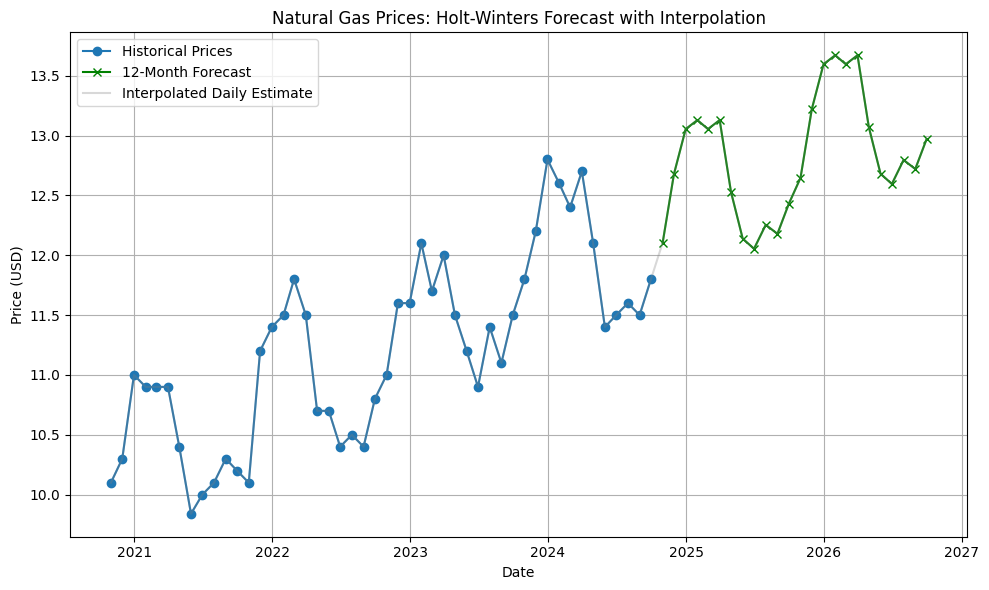

Estimated price on 2023-11-15: $12.00
Estimated price on 2025-05-15: $12.34


In [52]:
data = load_and_prepare_data("natural_gas_prices.csv")
forecast_df = fit_holt_winters(data, 24)
full_daily = combine_and_interpolate(data, forecast_df)
plot_prices(data, forecast_df, full_daily)

# Example usage
for test_date in [
    "2023-11-15",  # Within historical range
    "2025-05-15",  # Future date within forecast range
]:
    price = estimate_price(test_date, full_daily)
    print(f"Estimated price on {test_date}: ${price:.2f}")